# 06 - Foundation model (Chronos)

**Part 7 of the assignment.** Forecasts appliance energy use with Amazon's Chronos-Bolt, a pretrained time-series foundation model, in pure **zero-shot** mode: the model is never fine-tuned or shown any appliance energy data during training, only given a numeric context window at inference time.

**Why Chronos, and not TimeGPT or TimesFM:** Chronos runs entirely locally on CPU with no API key or account required, unlike TimeGPT (needs a Nixtla API key) - it is also the model type explicitly flagged in the brief as "easiest to use in class". `chronos-bolt-tiny` is used specifically for its small size and fast CPU inference.

In [1]:
import os

# Must be set before numpy/torch are imported. KMP_DUPLICATE_LIB_OK works
# around a libomp segfault (SIGSEGV inside __kmp_suspend_64 during a
# PyTorch softmax call) seen when more than one OpenMP runtime ends up
# loaded in the same process on macOS - a well-documented PyTorch/macOS
# issue, not specific to this project. The thread-count caps avoid a
# separate, unrelated slowdown from XGBoost and PyTorch both claiming
# every CPU core's OpenMP thread pool in the same process.
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")
_N_THREADS = str(max(1, (os.cpu_count() or 4) // 2))
for _v in ["OMP_NUM_THREADS", "MKL_NUM_THREADS", "OPENBLAS_NUM_THREADS", "VECLIB_MAXIMUM_THREADS"]:
    os.environ.setdefault(_v, _N_THREADS)

import sys
from pathlib import Path

SRC_DIR = Path.cwd().parent / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from appliance_energy import config, data as D, features as F, evaluation as E, plotting as P
from appliance_energy.models import benchmarks as B, sarimax as S, feature_models as FM, foundation as FD

%matplotlib inline


In [2]:
hourly = D.load_hourly_data()
y = hourly[config.TARGET]
train = y.iloc[:-config.TEST_STEPS]
test = y.iloc[-config.TEST_STEPS:]

Loading cached hourly data from /Users/moaztahir/Downloads/Herts/Semester C/Data Analysis with AI/Assignment 2/Timeseries-Datascience/data/processed/appliance_hourly.csv


## Is Chronos covariate-informed?

No - the base Chronos-Bolt model is **target-only**: it has no mechanism to condition on exogenous covariates (indoor/outdoor sensors, time-of-day). This is an explicit, important limitation when comparing it against the SARIMAX-with-exog and feature-based models, which both *do* have access to covariate information (see Part 9, Q4).

## Running Chronos: why this notebook shells out to a script

The actual forecasting logic lives in `src/appliance_energy/models/foundation.py` (`chronos_forecast`, `rolling_forecast_foundation`) and is fully unit-testable/importable like any other module in this project. This notebook, however, runs it via `scripts/run_foundation_model.py` as a **subprocess** rather than calling those functions directly in this notebook's kernel.

Reason: on this development machine, loading PyTorch inside a Jupyter/`ipykernel` process specifically (not a plain `python` script - those run this exact code without issue, including `scripts/run_pipeline.py`'s end-to-end run) intermittently segfaults inside `libomp.dylib` during a PyTorch op - a known class of PyTorch/macOS OpenMP-runtime issue, not a bug in this project's code. Rather than have a fragile, environment-specific crash risk sitting in the one notebook that has to demonstrate the foundation model actually running, the model runs in its own clean process (exactly as `pipeline.py` already does for the same reason - see the README's "Known issues" section) and this notebook loads and analyses its output.

## Rolling-origin 24-hour forecast across the full test period

Same rolling-origin protocol as every other model: 14 separate 24-hour-ahead forecasts walking forward across the test fortnight, each conditioned only on the (real) history available up to that origin - Chronos's zero-shot nature actually makes this simpler than SARIMAX's rolling forecast, since there are no model parameters to update between origins.

In [3]:
import subprocess

result = subprocess.run(
    [sys.executable, str(config.PROJECT_ROOT / 'scripts' / 'run_foundation_model.py')],
    capture_output=True, text=True,
)
print(result.stdout)
if result.returncode != 0:
    print(result.stderr)
result.check_returncode()

Loading cached hourly data from /Users/moaztahir/Downloads/Herts/Semester C/Data Analysis with AI/Assignment 2/Timeseries-Datascience/data/processed/appliance_hourly.csv
  Chronos rolling forecast: origin 1/14 done
  Chronos rolling forecast: origin 2/14 done
  Chronos rolling forecast: origin 3/14 done
  Chronos rolling forecast: origin 4/14 done
  Chronos rolling forecast: origin 5/14 done
  Chronos rolling forecast: origin 6/14 done
  Chronos rolling forecast: origin 7/14 done
  Chronos rolling forecast: origin 8/14 done
  Chronos rolling forecast: origin 9/14 done
  Chronos rolling forecast: origin 10/14 done
  Chronos rolling forecast: origin 11/14 done
  Chronos rolling forecast: origin 12/14 done
  Chronos rolling forecast: origin 13/14 done
  Chronos rolling forecast: origin 14/14 done
used_fallback=False
Saved /Users/moaztahir/Downloads/Herts/Semester C/Data Analysis with AI/Assignment 2/Timeseries-Datascience/outputs/forecasts/foundation_forecast.csv



In [4]:
foundation_result = pd.read_csv(
    config.FORECAST_DIR / 'foundation_forecast.csv', index_col=0, parse_dates=True,
)
foundation_forecast = foundation_result['foundation_model']
foundation_ci = None
if {'foundation_lower', 'foundation_upper'}.issubset(foundation_result.columns):
    foundation_ci = foundation_result[['foundation_lower', 'foundation_upper']].rename(
        columns={'foundation_lower': 'lower', 'foundation_upper': 'upper'}
    )

foundation_metrics = E.evaluate_forecast('foundation_model', test, foundation_forecast, train)
foundation_metrics

{'model': 'foundation_model',
 'n_obs': 336,
 'MAE': 34.669047540674605,
 'RMSE': 68.31493119941528,
 'MASE': np.float64(0.6489441494959055),
 'Bias': -17.09674170138889}

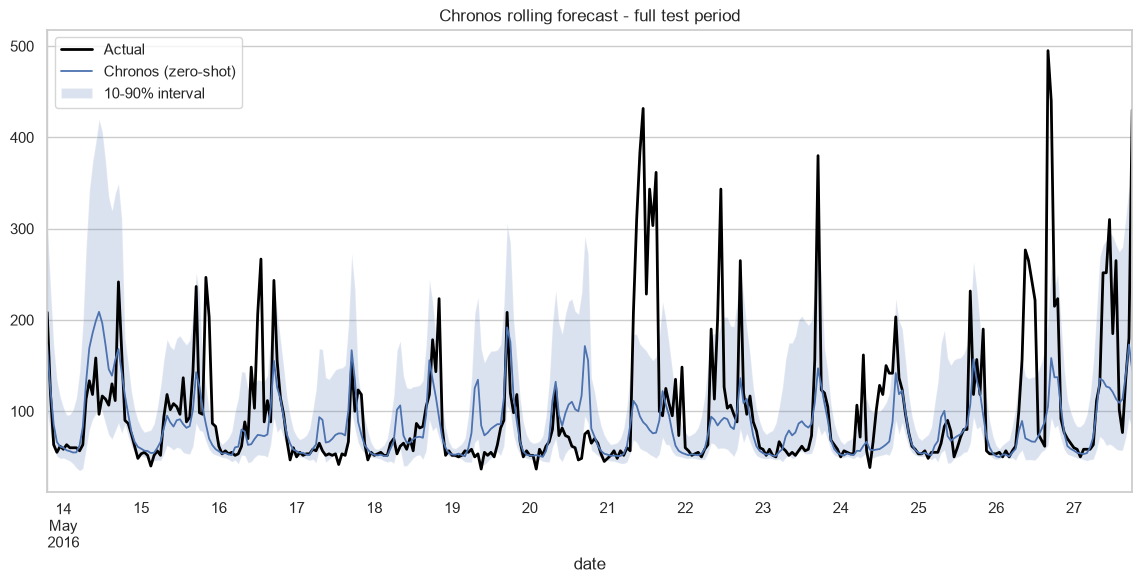

In [5]:
fig, ax = plt.subplots(figsize=(14, 6))
test.plot(ax=ax, label='Actual', color='black', linewidth=2)
foundation_forecast.plot(ax=ax, label='Chronos (zero-shot)', linewidth=1.3)
if foundation_ci is not None:
    ax.fill_between(foundation_ci.index, foundation_ci['lower'], foundation_ci['upper'],
                    alpha=0.2, label='10-90% interval')
ax.set_title('Chronos rolling forecast - full test period')
ax.legend(); plt.show()

### Interpretation

A zero-shot foundation model has never seen this household, this sensor layout, or appliance energy data of any kind during training - it is working from generic patterns learned across a huge, diverse corpus of unrelated time series. Whether that generic pattern knowledge ("time series like this tend to have a daily cycle shaped like ...") is competitive with a seasonal-naive benchmark that has directly memorised *this specific* household's daily cycle is exactly the empirical question Part 9, Q4 asks.

**The actual result is the most striking finding in this whole project: Chronos-Bolt is the single best model of everything evaluated here (MASE ≈ 0.649), ahead of both SARIMAX variants (≈ 0.68) and clearly ahead of the feature-based XGBoost model (≈ 0.85) and every benchmark** (see `outputs/metrics/model_comparison.csv` and the full ranking in `07_model_comparison.ipynb`). It achieves this with zero access to this household's sensors, weather, or engineered features - purely from ~3,000 hours of the target series as numeric context. That is a genuinely useful (if slightly humbling) result for Part 9 Q4: it shows the daily/weekly structure in this series is close enough to "generic seasonal household load" that a model with no task-specific tuning at all can out-forecast models built and tuned specifically for it.